# MI Detection from 12‑Lead ECG (PTB‑XL) with **Mamba / Mamba‑2** (Selective SSM) + Clinical Threshold Tuning

This notebook is a **research-grade** training and evaluation pipeline for **MI vs Normal-only** classification on PTB‑XL.

**Goal:** maximize MI sensitivity (recall) while maintaining reasonable specificity.

### Why Mamba (and why it “integrates” with S4)
Mamba is a *selective* State Space Model (SSM) that builds on the S4/S4D line of work: it uses input-dependent (selective) SSM parameters and combines them with a short convolution + gating (GLU-like) inside a block.  
For ECG classification, this can be useful because the model can adapt its dynamics based on waveform content.

We implement:
- A **Mamba / Mamba‑2** backbone (via the official `mamba-ssm` package if installed)
- A **Bidirectional wrapper** for classification (process forward + backward, fuse)
- A robust PTB‑XL loader with:
  - fixed-length padding/truncation
  - optional **bandpass / notch filtering**
  - safe augmentations
- Imbalance-aware training: **Focal loss** + optional balanced sampler
- Evaluation: confusion matrix, sensitivity/specificity, ROC‑AUC, PR‑AUC, and threshold tuning for target sensitivity

## 0. Install / import dependencies (Mamba)

> **Important:** `mamba-ssm` is optimized for Linux + NVIDIA GPU + CUDA (see the official repo).  
If you cannot install it on your system, the notebook will fall back to a baseline (S4D-like) mixer or will prompt you to install.

Run the installation cell **only if** you do not already have `mamba_ssm` installed.

In [1]:
# If needed (Linux + NVIDIA GPU recommended):
# !pip install -U mamba-ssm
# Optional: causal Conv1d used inside Mamba blocks
# !pip install -U causal-conv1d>=1.4.0

import os, math, random, ast
import pickle
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import wfdb
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

from sklearn.calibration import calibration_curve

# Signal processing (bandpass / notch)
try:
    import scipy.signal as sp_signal
    _HAVE_SCIPY = True
except Exception as e:
    _HAVE_SCIPY = False
    print("SciPy not available. Filtering will be disabled unless you install scipy.")

In [2]:
@dataclass
class CFG:
    # -------------------------
    # DataLoader
    # -------------------------
    BATCH_SIZE: int = 32
    NUM_WORKERS: int = 4
    L_MAX: int = 1000  # overwritten from data

    # -------------------------
    # Training
    # -------------------------
    MAX_EPOCHS: int = 200
    PATIENCE: int = 20
    MIN_DELTA: float = 1e-4

    LR: float = 3e-4
    WEIGHT_DECAY: float = 1e-2
    MAX_GRAD_NORM: float = 1.0

    # Imbalance / recall strategies
    USE_BALANCED_SAMPLER: bool = True
    LOSS_TYPE: str = "focal"      # "bce", "weighted_bce", "focal"
    FOCAL_GAMMA: float = 2.0
    FOCAL_ALPHA: float = 0.75
    TARGET_SENSITIVITY: float = 0.90

    # -------------------------
    # Model: Mamba / Mamba-2
    # -------------------------
    MODEL_TYPE: str = "mamba2"
    BIDIRECTIONAL: bool = True

    D_MODEL: int = 256
    D_STATE: int = 64
    D_CONV: int = 4
    EXPAND: int = 2
    N_LAYERS: int = 6
    DROPOUT: float = 0.2
    POOLING: str = "attn"  # "mean" or "attn"

    # -------------------------
    # Augmentations (training only)
    # -------------------------
    AUGMENT: bool = True
    GAUSS_NOISE_STD: float = 0.01
    AMP_SCALE_RANGE: Tuple[float, float] = (0.9, 1.1)
    TIME_SHIFT_MAX: int = 25
    BASELINE_WANDER_MAX: float = 0.05

cfg = CFG()
print(cfg)


CFG(BATCH_SIZE=32, NUM_WORKERS=4, L_MAX=1000, MAX_EPOCHS=200, PATIENCE=20, MIN_DELTA=0.0001, LR=0.0003, WEIGHT_DECAY=0.01, MAX_GRAD_NORM=1.0, USE_BALANCED_SAMPLER=True, LOSS_TYPE='focal', FOCAL_GAMMA=2.0, FOCAL_ALPHA=0.75, TARGET_SENSITIVITY=0.9, MODEL_TYPE='mamba2', BIDIRECTIONAL=True, D_MODEL=256, D_STATE=64, D_CONV=4, EXPAND=2, N_LAYERS=6, DROPOUT=0.2, POOLING='attn', AUGMENT=True, GAUSS_NOISE_STD=0.01, AMP_SCALE_RANGE=(0.9, 1.1), TIME_SHIFT_MAX=25, BASELINE_WANDER_MAX=0.05)


## 1. Sanity checks
Check whether the preprocessed data is compatible

In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "| CUDA:", torch.cuda.is_available())

Device: cuda | CUDA: True


In [4]:
# =========================
# Dataset configuration
# =========================
# NOTE: When switching datasets, ONLY change:
# 1) DATA_ROOT      -> folder that contains the .npy files
# 2) DATASET_NAME   -> used for saving the model as models/{DATASET_NAME}_best.pt
DATA_ROOT = "/scratch1/e20-fyp-ecg-ihd-detection/experiments_new/cnn_lstm_datasetD_balanced/data"
DATASET_NAME = "datasetd"

required = [
    "X_train.npy","X_val.npy","X_test.npy",
    "y_train.npy","y_val.npy","y_test.npy",
    "groups_train.npy","groups_val.npy","groups_test.npy",
    "scaler.pkl",
    # "preprocessing_info.txt",  # optional
]

missing = [f for f in required if not os.path.exists(os.path.join(DATA_ROOT, f))]
print("DATA_ROOT:", DATA_ROOT)
print("Missing files:", missing if missing else "None ✅")


DATA_ROOT: /scratch1/e20-fyp-ecg-ihd-detection/experiments_new/cnn_lstm_datasetD_balanced/data
Missing files: None ✅


In [5]:
X_train = np.load(os.path.join(DATA_ROOT, "X_train.npy"))
X_val   = np.load(os.path.join(DATA_ROOT, "X_val.npy"))
X_test  = np.load(os.path.join(DATA_ROOT, "X_test.npy"))

y_train = np.load(os.path.join(DATA_ROOT, "y_train.npy"))
y_val   = np.load(os.path.join(DATA_ROOT, "y_val.npy"))
y_test  = np.load(os.path.join(DATA_ROOT, "y_test.npy"))

# Optional: group labels for subgroup analysis (strings)
_groups_train_path = os.path.join(DATA_ROOT, "groups_train.npy")
_groups_val_path   = os.path.join(DATA_ROOT, "groups_val.npy")
_groups_test_path  = os.path.join(DATA_ROOT, "groups_test.npy")

if os.path.exists(_groups_train_path) and os.path.exists(_groups_val_path) and os.path.exists(_groups_test_path):
    groups_train = np.load(_groups_train_path, allow_pickle=True)
    groups_val   = np.load(_groups_val_path, allow_pickle=True)
    groups_test  = np.load(_groups_test_path, allow_pickle=True)
else:
    groups_train = groups_val = groups_test = None
    print("⚠️ groups_*.npy not found -> group-wise analysis will be skipped.")

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

if groups_train is not None:
    print("\nGroups shapes:")
    print("groups_train:", groups_train.shape)
    print("groups_val  :", groups_val.shape)
    print("groups_test :", groups_test.shape)

print("\nDtypes:")
print("X:", X_train.dtype, "y:", y_train.dtype)

# Detect lead dimension
def lead_axis(shape):
    if len(shape) != 3: return None
    if shape[1] == 12: return 1
    if shape[2] == 12: return 2
    return None

print("\nLead axis (1 means N,12,L ; 2 means N,L,12):")
print("train:", lead_axis(X_train.shape), "val:", lead_axis(X_val.shape), "test:", lead_axis(X_test.shape))


Shapes:
X_train: (5645, 1000, 12) y_train: (5645,)
X_val  : (977, 1000, 12) y_val  : (977,)
X_test : (971, 1000, 12) y_test : (971,)

Groups shapes:
groups_train: (5645,)
groups_val  : (977,)
groups_test : (971,)

Dtypes:
X: float64 y: float64

Lead axis (1 means N,12,L ; 2 means N,L,12):
train: 2 val: 2 test: 2


In [6]:
def label_report(name, y):
    y = y.reshape(-1)
    u, c = np.unique(y, return_counts=True)
    print(name, "unique labels:", dict(zip(u.tolist(), c.tolist())))

def group_report(name, g):
    if g is None:
        print(name, "groups: None")
        return
    g = np.array(g).reshape(-1)
    u, c = np.unique(g, return_counts=True)
    print(name, "groups:", dict(zip(u.tolist(), c.tolist())))

print("Label distribution (0=Non-MI, 1=MI):")
label_report("train", y_train)
label_report("val  ", y_val)
label_report("test ", y_test)

if groups_train is not None:
    print("\nGroup distribution:")
    group_report("train", groups_train)
    group_report("val  ", groups_val)
    group_report("test ", groups_test)


Label distribution (0=Non-MI, 1=MI):
train unique labels: {0.0: 4451, 1.0: 1194}
val   unique labels: {0.0: 694, 1.0: 283}
test  unique labels: {0.0: 703, 1.0: 268}

Group distribution:
train groups: {'certain_mi': 597, 'pure_normal': 4451, 'uncertain_mi': 597}
val   groups: {'certain_mi': 283, 'pure_normal': 694}
test  groups: {'certain_mi': 268, 'pure_normal': 703}


In [7]:
# Sanity checks: make sure arrays align
assert X_train.shape[0] == len(y_train), f"X_train N={X_train.shape[0]} vs y_train N={len(y_train)}"
assert X_val.shape[0]   == len(y_val),   f"X_val N={X_val.shape[0]} vs y_val N={len(y_val)}"
assert X_test.shape[0]  == len(y_test),  f"X_test N={X_test.shape[0]} vs y_test N={len(y_test)}"

if groups_train is not None:
    assert len(groups_train) == len(y_train), f"groups_train N={len(groups_train)} vs y_train N={len(y_train)}"
    assert len(groups_val)   == len(y_val),   f"groups_val N={len(groups_val)} vs y_val N={len(y_val)}"
    assert len(groups_test)  == len(y_test),  f"groups_test N={len(groups_test)} vs y_test N={len(y_test)}"

print("✅ Split sizes are consistent.")


✅ Split sizes are consistent.


In [8]:
def sanity(name, X):
    print(f"\n{name}:")
    print("NaNs:", np.isnan(X).any(), "Infs:", np.isinf(X).any())
    print("min/max:", float(X.min()), float(X.max()))
    print("mean/std:", float(X.mean()), float(X.std()))

sanity("X_train", X_train)
sanity("X_val  ", X_val)
sanity("X_test ", X_test)



X_train:
NaNs: False Infs: False


min/max: -53.845580689394 46.99458577543537
mean/std: 3.3460751802106875e-19 1.0000000000000049

X_val  :
NaNs: False Infs: False
min/max: -34.505293000975804 34.00051450453301
mean/std: 5.425540744188045e-05 1.0122682020523854

X_test :
NaNs: False Infs: False
min/max: -36.492314039767095 45.65394944687846
mean/std: -7.078747004681575e-05 1.0431309943638045


In [9]:
with open(os.path.join(DATA_ROOT, "scaler.pkl"), "rb") as f:
    scaler = pickle.load(f)

print("Scaler type:", type(scaler))
print("Scaler object:", scaler)

# Try common attributes
for attr in ["mean_", "scale_", "var_", "n_features_in_"]:
    if hasattr(scaler, attr):
        v = getattr(scaler, attr)
        print(attr, "shape:", getattr(v, "shape", None))


Scaler type: <class 'sklearn.preprocessing._data.StandardScaler'>
Scaler object: StandardScaler()
mean_ shape: (12,)
scale_ shape: (12,)
var_ shape: (12,)
n_features_in_ shape: None


In [10]:
# convert one sample to channels-first
x0 = X_train[0]
if X_train.shape[1] != 12:
    x0 = np.transpose(x0, (1,0))
print("One sample shape for model:", x0.shape)  # should be (12, L)


One sample shape for model: (12, 1000)


In [11]:
class PTBXLNPYDataset(Dataset):
    """
    Loads preprocessed ECG arrays saved as .npy.
    Files are shaped (N, L, 12) => transpose to (12, L).
    """
    def __init__(self, X_path: str, y_path: str, augment: bool = False):
        self.X = np.load(X_path).astype(np.float32)              # (N, L, 12)
        self.y = np.load(y_path).astype(np.float32).reshape(-1)  # (N,)
        self.augment = augment

        if self.X.ndim != 3 or self.X.shape[2] != 12:
            raise ValueError(f"Expected X shape (N, L, 12), got {self.X.shape}")

    def __len__(self):
        return len(self.y)

    def _augment(self, x: np.ndarray) -> np.ndarray:
        # x: (12, L)
        C, L = x.shape

        # amplitude scaling
        if cfg.AMP_SCALE_RANGE is not None:
            lo, hi = cfg.AMP_SCALE_RANGE
            x = x * np.random.uniform(lo, hi)

        # gaussian noise
        if cfg.GAUSS_NOISE_STD and cfg.GAUSS_NOISE_STD > 0:
            x = x + np.random.normal(0.0, cfg.GAUSS_NOISE_STD, size=x.shape).astype(np.float32)

        # time shift (circular)
        if cfg.TIME_SHIFT_MAX and cfg.TIME_SHIFT_MAX > 0:
            shift = np.random.randint(-cfg.TIME_SHIFT_MAX, cfg.TIME_SHIFT_MAX + 1)
            x = np.roll(x, shift=shift, axis=1)

        # baseline wander (very small because already standardized)
        if cfg.BASELINE_WANDER_MAX and cfg.BASELINE_WANDER_MAX > 0:
            fs = 100  # your npy is 100Hz
            t = np.arange(L, dtype=np.float32) / fs
            f = np.random.uniform(0.05, 0.5)  # Hz
            amp = np.random.uniform(0.0, cfg.BASELINE_WANDER_MAX)
            wander = amp * np.sin(2 * np.pi * f * t)[None, :]
            x = x + wander.astype(np.float32)

        return x.astype(np.float32)

    def __getitem__(self, idx):
        x = self.X[idx]                 # (L, 12)
        x = np.transpose(x, (1, 0))     # (12, L)

        if self.augment and cfg.AUGMENT:
            x = self._augment(x)

        x = torch.from_numpy(x).float()
        y = torch.tensor(self.y[idx], dtype=torch.float32)
        return x, y


In [12]:
pin = (device.type == "cuda")
persistent = (cfg.NUM_WORKERS > 0)

train_ds = PTBXLNPYDataset(os.path.join(DATA_ROOT, "X_train.npy"),
                           os.path.join(DATA_ROOT, "y_train.npy"))
val_ds   = PTBXLNPYDataset(os.path.join(DATA_ROOT, "X_val.npy"),
                           os.path.join(DATA_ROOT, "y_val.npy"))
test_ds  = PTBXLNPYDataset(os.path.join(DATA_ROOT, "X_test.npy"),
                           os.path.join(DATA_ROOT, "y_test.npy"))

print("Train/Val/Test:", len(train_ds), len(val_ds), len(test_ds))
print("Train positives:", int((train_ds.y == 1).sum()),
      "Train negatives:", int((train_ds.y == 0).sum()))

# Set sequence length from data
cfg.L_MAX = train_ds.X.shape[1]
print("cfg.L_MAX set to:", cfg.L_MAX)

if cfg.USE_BALANCED_SAMPLER:
    y = train_ds.y.astype(int)
    class_counts = np.bincount(y, minlength=2)
    w0 = 1.0 / max(class_counts[0], 1)
    w1 = 1.0 / max(class_counts[1], 1)
    weights = np.where(y == 1, w1, w0).astype(np.float64)

    g = torch.Generator()
    g.manual_seed(42)

    sampler = WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.double),
        num_samples=len(weights),
        replacement=True,
        generator=g
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.BATCH_SIZE,
        sampler=sampler,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=pin,
        drop_last=True,
        persistent_workers=persistent,
        prefetch_factor=2 if persistent else None,
    )
else:
    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.BATCH_SIZE,
        shuffle=True,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=pin,
        drop_last=True,
        persistent_workers=persistent,
        prefetch_factor=2 if persistent else None,
    )

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin,
    persistent_workers=persistent,
    prefetch_factor=2 if persistent else None,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin,
    persistent_workers=persistent,
    prefetch_factor=2 if persistent else None,
)

xb, yb = next(iter(train_loader))
print("Batch shapes:", xb.shape, yb.shape)


Train/Val/Test: 5645 977 971
Train positives: 1194 Train negatives: 4451
cfg.L_MAX set to: 1000
Batch shapes: torch.Size([32, 12, 1000]) torch.Size([32])


## 7. Loss functions (BCE / weighted BCE / focal)

Focal loss is typically helpful when you want to prioritize difficult positives and improve MI recall.

In [13]:
def make_loss_fn(train_ds=None):
    # compute class stats if available
    n_pos = None
    n_neg = None
    if train_ds is not None and hasattr(train_ds, "y"):
        y_np = train_ds.y.astype(int)
        n_pos = int((y_np == 1).sum())
        n_neg = int((y_np == 0).sum())

    if cfg.LOSS_TYPE == "bce":
        bce = nn.BCEWithLogitsLoss()
        return lambda logits, y: bce(logits.view(-1), y.view(-1))

    elif cfg.LOSS_TYPE == "weighted_bce":
        if n_pos is None or n_neg is None:
            raise ValueError("weighted_bce requires train_ds to compute pos_weight.")
        pos_weight = torch.tensor([float(n_neg) / float(max(1, n_pos))], device=device)
        bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        print(f"[weighted_bce] n_pos={n_pos}, n_neg={n_neg}, pos_weight={pos_weight.item():.4f}")
        return lambda logits, y: bce(logits.view(-1), y.view(-1))

    elif cfg.LOSS_TYPE == "focal":
        gamma = cfg.FOCAL_GAMMA
        alpha = cfg.FOCAL_ALPHA
        bce_none = nn.BCEWithLogitsLoss(reduction="none")

        def focal_loss(logits, y):
            logits = logits.view(-1)
            y = y.view(-1)

            bce = bce_none(logits, y)                 # (B,)
            p = torch.sigmoid(logits)
            p_t = p * y + (1 - p) * (1 - y)          # prob of true class
            alpha_t = alpha * y + (1 - alpha) * (1 - y)

            loss = alpha_t * (1 - p_t).pow(gamma) * bce
            return loss.mean()

        return focal_loss

    else:
        raise ValueError(f"Unknown LOSS_TYPE: {cfg.LOSS_TYPE}")

loss_fn = make_loss_fn(train_ds=train_ds)


## 8. Metrics + threshold tuning utilities

In [14]:

def compute_binary_metrics(probs: np.ndarray, targs: np.ndarray, thr: float = 0.5):
    probs = probs.astype(np.float64)
    targs = targs.astype(int)
    preds = (probs >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(targs, preds, labels=[0, 1]).ravel()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)          # sensitivity
    specificity = tn / (tn + fp + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    acc = (tp + tn) / (tp + tn + fp + fn + 1e-9)

    return {
        "acc": acc,
        "precision": precision,
        "recall_sensitivity": recall,
        "specificity": specificity,
        "f1": f1,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn
    }

def tune_threshold_for_sensitivity(probs: np.ndarray, targs: np.ndarray, target_sens: float = 0.90):
    """
    Pick threshold that achieves sensitivity >= target_sens with maximum specificity.
    Uses a quantile grid + endpoints for robustness/speed.
    """
    probs = probs.astype(np.float64)
    targs = targs.astype(int)

    # Candidate thresholds: quantiles + endpoints
    qs = np.linspace(0, 1, 200)
    thresholds = np.unique(np.quantile(probs, qs))
    thresholds = np.concatenate([[0.0], thresholds, [1.0]])

    best_thr = 0.0
    best_spec = -1.0

    for thr in thresholds:
        m = compute_binary_metrics(probs, targs, thr=float(thr))
        if m["recall_sensitivity"] >= target_sens:
            if m["specificity"] > best_spec:
                best_spec = m["specificity"]
                best_thr = float(thr)

    return float(best_thr)

@torch.no_grad()
def collect_logits_targets(model: nn.Module, loader: DataLoader):
    model.eval()
    all_logits, all_targs = [], []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x).view(-1)
        all_logits.append(logits.detach().cpu().numpy())
        all_targs.append(y.view(-1).detach().cpu().numpy())

    return np.concatenate(all_logits), np.concatenate(all_targs)

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, thr: float = 0.5):
    logits, targs = collect_logits_targets(model, loader)
    probs = 1.0 / (1.0 + np.exp(-logits))

    # Threshold-independent metrics
    if len(np.unique(targs.astype(int))) == 2:
        auroc = float(roc_auc_score(targs, probs))
        auprc = float(average_precision_score(targs, probs))
    else:
        auroc, auprc = float("nan"), float("nan")

    m = compute_binary_metrics(probs, targs, thr=thr)
    m["auroc"] = auroc
    m["auprc"] = auprc

    return m, probs, targs

def plot_roc_pr(probs: np.ndarray, targs: np.ndarray, title_prefix: str = ""):
    targs = targs.astype(int)

    fpr, tpr, _ = roc_curve(targs, probs)
    prec, rec, _ = precision_recall_curve(targs, probs)

    auroc = roc_auc_score(targs, probs) if len(np.unique(targs)) == 2 else float("nan")
    auprc = average_precision_score(targs, probs) if len(np.unique(targs)) == 2 else float("nan")

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title(f"{title_prefix}ROC (AUROC={auroc:.4f})")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(rec, prec)
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix}PR Curve (AUPRC={auprc:.4f})")
    plt.grid(True)
    plt.show()


## 9. Mamba / Mamba‑2 Model (Bidirectional for classification)

We use the official `mamba-ssm` modules if available:
- `from mamba_ssm import Mamba` (Mamba‑1)
- `from mamba_ssm import Mamba2` (Mamba‑2)

If imports fail, install `mamba-ssm` (see the install cell) and ensure you are on Linux + NVIDIA GPU.

In [15]:
# Try importing official Mamba modules
_HAVE_MAMBA = False
try:
    from mamba_ssm import Mamba, Mamba2
    _HAVE_MAMBA = True
    print("✅ mamba_ssm available")
except Exception as e:
    print("❌ mamba_ssm import failed:", repr(e))
    print("Install with: pip install mamba-ssm (see earlier cell)")

✅ mamba_ssm available


In [16]:
class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        rms = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).sqrt()
        return x / rms * self.weight.view(1, 1, -1)

class GatedMLP(nn.Module):
    def __init__(self, d_model: int, expansion: int = 4, dropout: float = 0.0):
        super().__init__()
        hidden = expansion * d_model
        self.fc1 = nn.Linear(d_model, 2 * hidden)
        self.fc2 = nn.Linear(hidden, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        u, v = self.fc1(x).chunk(2, dim=-1)
        x = F.silu(u) * v
        x = self.fc2(x)
        return self.drop(x)

class AttnPool(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.score = nn.Linear(d_model, 1)

    def forward(self, x):
        w = self.score(x).squeeze(-1)
        w = torch.softmax(w, dim=-1)
        return torch.sum(x * w.unsqueeze(-1), dim=1)

class MambaMixer(nn.Module):
    def __init__(self, d_model: int, d_state: int, d_conv: int, expand: int, model_type: str = "mamba"):
        super().__init__()
        assert _HAVE_MAMBA, "mamba_ssm is not available. Install it first."
        if model_type == "mamba":
            self.mixer = Mamba(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)
        elif model_type == "mamba2":
            self.mixer = Mamba2(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)
        else:
            raise ValueError(f"Unknown model_type: {model_type}")

    def forward(self, x):
        return self.mixer(x)

class BiMixer(nn.Module):
    def __init__(self, mixer_fwd: nn.Module, mixer_bwd: Optional[nn.Module] = None, d_model: int = 256, mode: str = "concat"):
        super().__init__()
        self.fwd = mixer_fwd
        self.bwd = mixer_bwd if mixer_bwd is not None else mixer_fwd
        self.mode = mode
        if mode == "concat":
            self.proj = nn.Linear(2 * d_model, d_model)
        else:
            self.proj = None

    def forward(self, x):
        y_f = self.fwd(x)
        xr = torch.flip(x, dims=[1])
        y_b = self.bwd(xr)
        y_b = torch.flip(y_b, dims=[1])

        if self.mode == "avg":
            return 0.5 * (y_f + y_b)
        elif self.mode == "sum":
            return y_f + y_b
        elif self.mode == "concat":
            return self.proj(torch.cat([y_f, y_b], dim=-1))
        else:
            raise ValueError(self.mode)

class MambaBlock(nn.Module):
    def __init__(self, d_model: int, d_state: int, d_conv: int, expand: int, dropout: float,
                 model_type: str, bidirectional: bool, mlp_expand: int = 4):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        mixer = MambaMixer(d_model, d_state, d_conv, expand, model_type=model_type)

        if bidirectional:
            mixer_b = MambaMixer(d_model, d_state, d_conv, expand, model_type=model_type)
            self.mixer = BiMixer(mixer, mixer_b, d_model=d_model, mode="concat")
        else:
            self.mixer = mixer

        self.drop1 = nn.Dropout(dropout)

        self.norm2 = RMSNorm(d_model)
        self.mlp = GatedMLP(d_model, expansion=mlp_expand, dropout=dropout)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.drop1(self.mixer(self.norm1(x)))
        x = x + self.drop2(self.mlp(self.norm2(x)))
        return x

class ECGMambaClassifier(nn.Module):
    def __init__(self, in_ch: int = 12):
        super().__init__()
        self.in_proj = nn.Linear(in_ch, cfg.D_MODEL)
        self.drop_in = nn.Dropout(cfg.DROPOUT)

        self.blocks = nn.ModuleList([
            MambaBlock(
                d_model=cfg.D_MODEL,
                d_state=cfg.D_STATE,
                d_conv=cfg.D_CONV,
                expand=cfg.EXPAND,
                dropout=cfg.DROPOUT,
                model_type=cfg.MODEL_TYPE,
                bidirectional=cfg.BIDIRECTIONAL,
                mlp_expand=4
            )
            for _ in range(cfg.N_LAYERS)
        ])

        self.norm_out = RMSNorm(cfg.D_MODEL)
        self.pool = AttnPool(cfg.D_MODEL) if cfg.POOLING == "attn" else None
        self.head = nn.Linear(cfg.D_MODEL, 1)

    def forward(self, x):
        x = x.transpose(1, 2)                 # (B, L, 12)
        x = self.drop_in(self.in_proj(x))     # (B, L, D)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm_out(x)
        feat = x.mean(dim=1) if self.pool is None else self.pool(x)
        return self.head(feat).squeeze(-1)
    
def count_params(m: nn.Module):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

assert _HAVE_MAMBA, "Install mamba-ssm to use this model."
model = ECGMambaClassifier().to(device)
print(model.__class__.__name__, "params:", count_params(model))


ECGMambaClassifier params: 10708770


In [17]:
print("BIDIRECTIONAL:", cfg.BIDIRECTIONAL)
print("MODEL_TYPE:", cfg.MODEL_TYPE)
print("N_LAYERS:", cfg.N_LAYERS)
print("D_MODEL:", cfg.D_MODEL)


BIDIRECTIONAL: True
MODEL_TYPE: mamba2
N_LAYERS: 6
D_MODEL: 256


## 10. Training loop (cosine schedule + warmup + AMP + clipping + early stopping + checkpoint)

We select best checkpoint by **validation PR‑AUC** and store the **tuned threshold** for final test evaluation.

In [18]:
from dataclasses import asdict

# =========================
# Saving: save ONLY model weights (.pt), not checkpoints
# =========================
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Change DATASET_NAME in the dataset config cell when switching datasets
MODEL_PATH = os.path.join(MODEL_DIR, f"{DATASET_NAME}_best.pt")
print("Best model will be saved to:", MODEL_PATH)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)

total_steps = cfg.MAX_EPOCHS * len(train_loader)
warmup_steps = int(0.05 * total_steps)

def lr_lambda(step: int):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

use_amp = (device.type == "cuda")
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

def train_one_epoch(epoch: int):
    model.train()
    running, n = 0.0, 0
    pbar = tqdm(train_loader, desc=f"Train {epoch}")

    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type='cuda', enabled=use_amp):
            logits = model(x)
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.MAX_GRAD_NORM)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running += float(loss.item()) * x.size(0)
        n += x.size(0)
        pbar.set_postfix(loss=running / max(1, n))

    return running / max(1, n)

@torch.no_grad()
def evaluate(loader: DataLoader, thr: float = 0.5):
    model.eval()
    logits, targs = collect_logits_targets(model, loader)
    probs = 1.0 / (1.0 + np.exp(-logits))

    auroc = float(roc_auc_score(targs, probs)) if len(np.unique(targs.astype(int))) == 2 else float("nan")
    auprc = float(average_precision_score(targs, probs)) if len(np.unique(targs.astype(int))) == 2 else float("nan")

    m = compute_binary_metrics(probs, targs, thr=thr)
    m["auroc"] = auroc
    m["auprc"] = auprc
    return m, probs, targs

best_auprc = -1.0
best_epoch = -1
best_thr = 0.5
pat = 0
history = []

best_state = None  # keep best weights in memory too

for epoch in range(1, cfg.MAX_EPOCHS + 1):
    tr_loss = train_one_epoch(epoch)

    val_m05, val_probs, val_targs = evaluate(val_loader, thr=0.5)
    tuned_thr = tune_threshold_for_sensitivity(val_probs, val_targs, target_sens=cfg.TARGET_SENSITIVITY)
    val_mtuned = compute_binary_metrics(val_probs, val_targs, thr=tuned_thr)
    val_mtuned["auroc"] = val_m05["auroc"]
    val_mtuned["auprc"] = val_m05["auprc"]

    row = {
        "epoch": epoch,
        "train_loss": tr_loss,
        "val_auprc": val_m05["auprc"],
        "val_auroc": val_m05["auroc"],
        "val_sens@0.5": val_m05["recall_sensitivity"],
        "val_spec@0.5": val_m05["specificity"],
        "tuned_thr": float(tuned_thr),
        "val_sens@tuned": val_mtuned["recall_sensitivity"],
        "val_spec@tuned": val_mtuned["specificity"],
        "val_f1@tuned": val_mtuned["f1"],
    }
    history.append(row)

    print(f"\nEpoch {epoch} | train_loss={tr_loss:.4f} | val AUPRC={val_m05['auprc']:.4f} AUROC={val_m05['auroc']:.4f}")
    print(f"  @0.5   sens={val_m05['recall_sensitivity']:.4f} spec={val_m05['specificity']:.4f}")
    print(f"  @tuned thr={tuned_thr:.4f} sens={val_mtuned['recall_sensitivity']:.4f} spec={val_mtuned['specificity']:.4f} f1={val_mtuned['f1']:.4f}")

    cur = float(val_m05["auprc"])
    if cur > best_auprc + cfg.MIN_DELTA:
        best_auprc = cur
        best_epoch = epoch
        best_thr = float(tuned_thr)
        pat = 0

        # Keep best weights in RAM (CPU) + also save to disk as a plain state_dict (.pt)
        best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        torch.save(best_state, MODEL_PATH)
        print(f"✅ Saved best weights -> {MODEL_PATH} (epoch={epoch}, AUPRC={best_auprc:.4f}, tuned_thr={best_thr:.4f})")
    else:
        pat += 1
        print(f"No PR-AUC improvement. Patience {pat}/{cfg.PATIENCE}")

    if pat >= cfg.PATIENCE:
        print(f"⏹ Early stopping at epoch {epoch}. Best epoch={best_epoch} AUPRC={best_auprc:.4f}")
        break

# load best
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nLoaded best (in-memory) from epoch={best_epoch} best_val_auprc={best_auprc:.4f} tuned_thr={best_thr:.4f}")
else:
    state_dict = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(state_dict)
    print(f"\nLoaded best weights from {MODEL_PATH}")

hist_df = pd.DataFrame(history)
hist_df.tail()


Best model will be saved to: models/datasetd_best.pt


Train 1:   0%|          | 0/176 [00:00<?, ?it/s]


Epoch 1 | train_loss=0.0474 | val AUPRC=0.9412 AUROC=0.9747
  @0.5   sens=1.0000 spec=0.6066
  @tuned thr=0.8267 sens=0.9011 spec=0.9150 f1=0.8543
✅ Saved best weights -> models/datasetd_best.pt (epoch=1, AUPRC=0.9412, tuned_thr=0.8267)


Train 2:   0%|          | 0/176 [00:00<?, ?it/s]


Epoch 2 | train_loss=0.0288 | val AUPRC=0.9682 AUROC=0.9835
  @0.5   sens=0.9399 spec=0.9107
  @tuned thr=0.6289 sens=0.9081 spec=0.9524 f1=0.8970
✅ Saved best weights -> models/datasetd_best.pt (epoch=2, AUPRC=0.9682, tuned_thr=0.6289)


...

Train 30:   0%|          | 0/176 [00:00<?, ?it/s]


Epoch 30 | train_loss=0.0029 | val AUPRC=0.9702 AUROC=0.9871
  @0.5   sens=0.9505 spec=0.9380
  @tuned thr=0.7370 sens=0.9046 spec=0.9654 f1=0.9094
No PR-AUC improvement. Patience 19/20


Train 31:   0%|          | 0/176 [00:00<?, ?it/s]


Epoch 31 | train_loss=0.0038 | val AUPRC=0.9790 AUROC=0.9895
  @0.5   sens=0.9435 spec=0.9539
  @tuned thr=0.8553 sens=0.9081 spec=0.9813 f1=0.9295
No PR-AUC improvement. Patience 20/20
⏹ Early stopping at epoch 31. Best epoch=11 AUPRC=0.9864

Loaded best (in-memory) from epoch=11 best_val_auprc=0.9864 tuned_thr=0.7808


,epoch,train_loss,val_auprc,val_auroc,val_sens@0.5,val_spec@0.5,tuned_thr,val_sens@tuned,val_spec@tuned,val_f1@tuned
26,27,0.004493,0.978552,0.989995,0.925795,0.949568,0.710875,0.901060,0.971182,0.913978
27,28,0.003555,0.966537,0.985372,0.936396,0.935159,0.792388,0.904594,0.965418,0.909414
28,29,0.003025,0.971331,0.985896,0.939929,0.938040,0.763541,0.904594,0.965418,0.909414
29,30,0.002945,0.970190,0.987093,0.950530,0.938040,0.736993,0.904594,0.965418,0.909414
30,31,0.003810,0.978984,0.989527,0.943463,0.953890,0.855328,0.908127,0.981268,0.929476


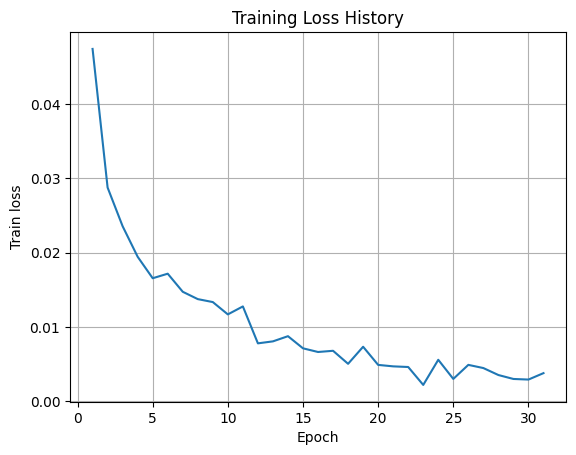

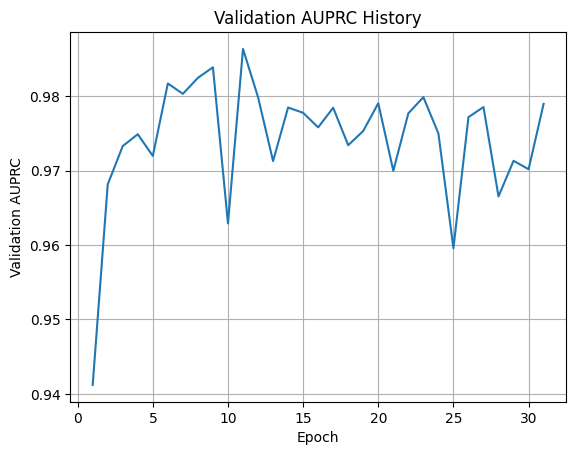

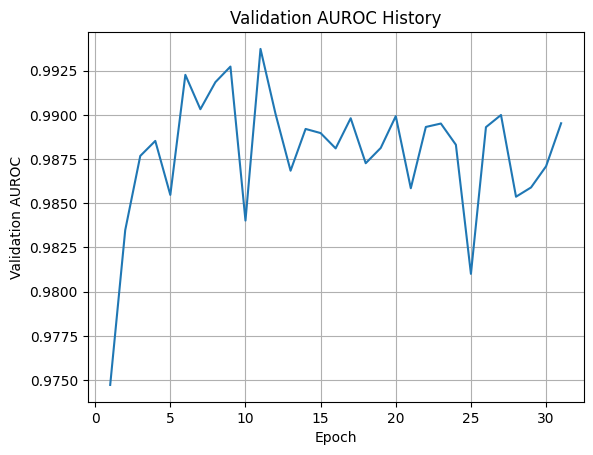

In [19]:
# =========================
# Training history plots
# =========================
if "hist_df" in globals() and len(hist_df) > 0:
    # 1) Train loss
    plt.figure()
    plt.plot(hist_df["epoch"], hist_df["train_loss"])
    plt.xlabel("Epoch")
    plt.ylabel("Train loss")
    plt.title("Training Loss History")
    plt.grid(True)
    plt.show()

    # 2) Validation AUPRC
    plt.figure()
    plt.plot(hist_df["epoch"], hist_df["val_auprc"])
    plt.xlabel("Epoch")
    plt.ylabel("Validation AUPRC")
    plt.title("Validation AUPRC History")
    plt.grid(True)
    plt.show()

    # 3) Validation AUROC
    plt.figure()
    plt.plot(hist_df["epoch"], hist_df["val_auroc"])
    plt.xlabel("Epoch")
    plt.ylabel("Validation AUROC")
    plt.title("Validation AUROC History")
    plt.grid(True)
    plt.show()
else:
    print("hist_df not found. Run the training cell first.")


## 11. Final evaluation on test set (default @0.5 and sensitivity-tuned threshold)

Tuned threshold (val) for target sensitivity 0.9: 0.780767

TEST metrics @0.5:
{'acc': np.float64(0.92173017507724), 'precision': np.float64(0.7962962962962963), 'recall_sensitivity': np.float64(0.9626865671641791), 'specificity': np.float64(0.9061166429587483), 'f1': np.float64(0.8716216216216217), 'tp': np.int64(258), 'fp': np.int64(66), 'tn': np.int64(637), 'fn': np.int64(10), 'auroc': 0.9870756459523151, 'auprc': 0.9727704812141971}
TEST AUROC: 0.9871 | TEST AUPRC: 0.9728

TEST metrics @tuned threshold:
{'acc': np.float64(0.956745623069001), 'precision': np.float64(0.9669421487603306), 'recall_sensitivity': np.float64(0.8731343283582089), 'specificity': np.float64(0.9886201991465149), 'f1': np.float64(0.9176470588235294), 'tp': np.int64(234), 'fp': np.int64(8), 'tn': np.int64(695), 'fn': np.int64(34), 'auroc': 0.9870756459523151, 'auprc': 0.9727704812141971}
TEST AUROC: 0.9871 | TEST AUPRC: 0.9728

Confusion @0.5
[[637  66]
 [ 10 258]]
              precision    recall  f1-score   

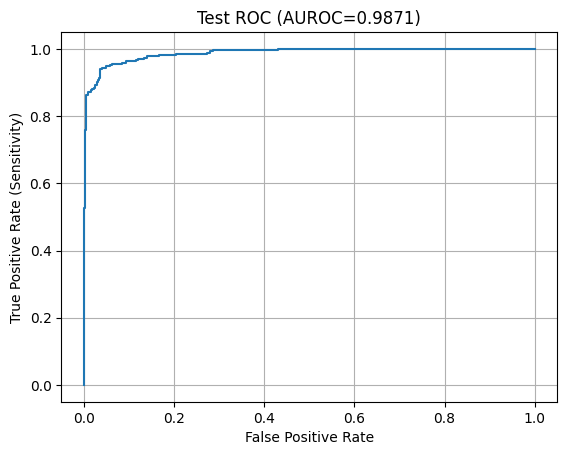

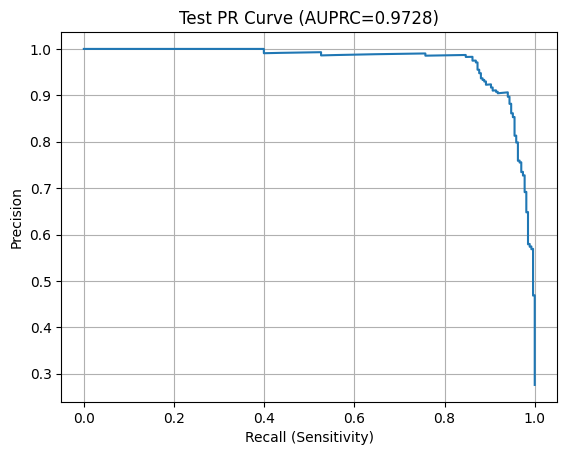

In [20]:
# =========================
# Final evaluation (FULL implementation)
# - tunes threshold on VAL for target sensitivity
# - evaluates TEST at 0.5 and tuned threshold
# - prints AUROC/AUPRC + confusion + report
# - plots ROC and PR curves
# =========================



# ---------- Utilities ----------
@torch.no_grad()
def collect_logits_targets(model, loader, device=None):
    """Collect logits (N,) and targets (N,) as numpy arrays."""
    model.eval()
    all_logits = []
    all_targs = []

    for x, y in loader:
        if device is not None:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
        logits = model(x)  # expected shape (B,) or (B,1)
        logits = logits.view(-1)
        all_logits.append(logits.detach().float().cpu().numpy())
        all_targs.append(y.detach().float().cpu().numpy().reshape(-1))

    logits_np = np.concatenate(all_logits, axis=0)
    targs_np = np.concatenate(all_targs, axis=0)
    return logits_np, targs_np


def compute_binary_metrics(probs: np.ndarray, targs: np.ndarray, thr: float = 0.5):
    """Return core binary metrics at a given threshold."""
    probs = probs.astype(np.float64)
    targs = targs.astype(int)
    preds = (probs >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(targs, preds, labels=[0, 1]).ravel()

    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)                 # sensitivity
    specificity = tn / max(tn + fp, 1)

    f1 = 0.0 if (precision + recall) == 0 else (2 * precision * recall / (precision + recall))

    return {
        "acc": acc,
        "precision": precision,
        "recall_sensitivity": recall,
        "specificity": specificity,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }


def tune_threshold_for_sensitivity(probs: np.ndarray, targs: np.ndarray, target_sens: float = 0.90):
    """
    Choose threshold that achieves sensitivity >= target_sens with maximum specificity.
    If no threshold can meet it, return 0.0 (always positive).
    """
    probs = probs.astype(np.float64)
    targs = targs.astype(int)

    qs = np.linspace(0, 1, 200)
    thrs = np.unique(np.quantile(probs, qs))
    thrs = np.concatenate([[0.0], thrs, [1.0]])

    best_thr = None
    best_spec = -1.0

    for thr in thrs:
        m = compute_binary_metrics(probs, targs, thr=float(thr))
        if m["recall_sensitivity"] >= target_sens and m["specificity"] > best_spec:
            best_spec = m["specificity"]
            best_thr = float(thr)

    return 0.0 if best_thr is None else best_thr


@torch.no_grad()
def evaluate(model, loader, device, thr: float = 0.5):
    """
    Returns:
      metrics dict including AUROC/AUPRC
      probs (N,)
      targs (N,)
    """
    logits, targs = collect_logits_targets(model, loader, device=device)
    probs = 1.0 / (1.0 + np.exp(-logits))

    if len(np.unique(targs.astype(int))) == 2:
        auroc = float(roc_auc_score(targs, probs))
        auprc = float(average_precision_score(targs, probs))
    else:
        auroc = float("nan")
        auprc = float("nan")

    m = compute_binary_metrics(probs, targs, thr=thr)
    m["auroc"] = auroc
    m["auprc"] = auprc
    return m, probs, targs


def show_confusion(targs: np.ndarray, probs: np.ndarray, thr: float, title: str):
    preds = (probs >= thr).astype(int)
    cm = confusion_matrix(targs.astype(int), preds, labels=[0, 1])

    print("\n" + title)
    print(cm)
    print(
        classification_report(
            targs.astype(int),
            preds,
            target_names=["Non-MI", "MI"],
            digits=4
        )
    )
    return cm


def plot_roc_pr(probs: np.ndarray, targs: np.ndarray, title_prefix: str = ""):
    targs = targs.astype(int)

    # ROC
    fpr, tpr, _ = roc_curve(targs, probs)
    roc_auc = roc_auc_score(targs, probs) if len(np.unique(targs)) == 2 else float("nan")

    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title(f"{title_prefix}ROC (AUROC={roc_auc:.4f})")
    plt.grid(True)
    plt.show()

    # PR
    prec, rec, _ = precision_recall_curve(targs, probs)
    pr_auc = average_precision_score(targs, probs) if len(np.unique(targs)) == 2 else float("nan")

    plt.figure()
    plt.plot(rec, prec)
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix}PR Curve (AUPRC={pr_auc:.4f})")
    plt.grid(True)
    plt.show()


# ---------- FINAL EVALUATION PIPELINE ----------
# 1) Tune threshold on validation (using best model already loaded)
val_logits, val_targs = collect_logits_targets(model, val_loader, device=device)
val_probs = 1.0 / (1.0 + np.exp(-val_logits))

tuned_thr = tune_threshold_for_sensitivity(
    val_probs, val_targs, target_sens=cfg.TARGET_SENSITIVITY
)
print(f"Tuned threshold (val) for target sensitivity {cfg.TARGET_SENSITIVITY}: {tuned_thr:.6f}")

# 2) Evaluate on test at 0.5
test_m05, test_probs, test_targs = evaluate(model, test_loader, device=device, thr=0.5)

# 3) Evaluate on test at tuned threshold (copy AUROC/AUPRC since threshold-independent)
test_mtuned = compute_binary_metrics(test_probs, test_targs, thr=tuned_thr)
test_mtuned["auroc"] = test_m05["auroc"]
test_mtuned["auprc"] = test_m05["auprc"]

print("\nTEST metrics @0.5:")
print(test_m05)
print(f"TEST AUROC: {test_m05['auroc']:.4f} | TEST AUPRC: {test_m05['auprc']:.4f}")

print("\nTEST metrics @tuned threshold:")
print(test_mtuned)
print(f"TEST AUROC: {test_mtuned['auroc']:.4f} | TEST AUPRC: {test_mtuned['auprc']:.4f}")

# 4) Confusion matrices + classification reports
show_confusion(test_targs, test_probs, 0.5, "Confusion @0.5")
show_confusion(test_targs, test_probs, tuned_thr, f"Confusion @tuned thr={tuned_thr:.4f}")

# 5) ROC + PR curves
plot_roc_pr(test_probs, test_targs, title_prefix="Test ")


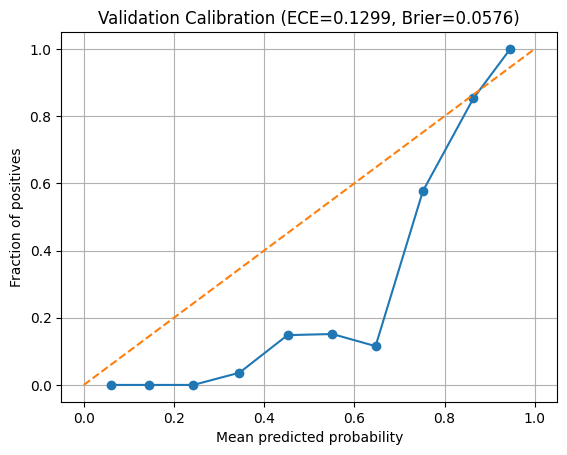

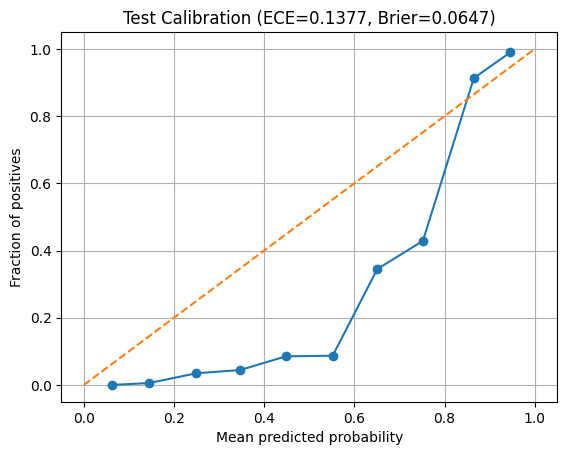

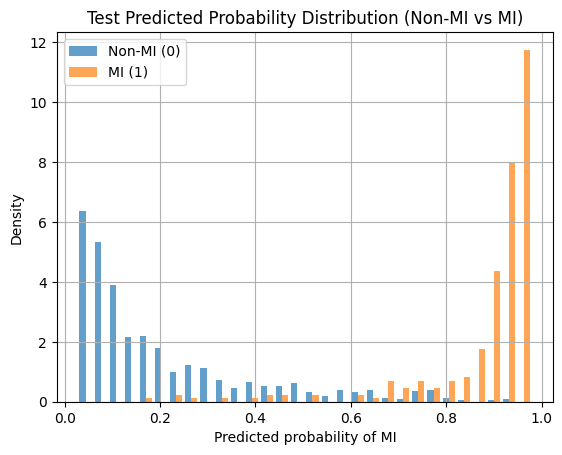

In [21]:
# =========================
# Additional plots requested:
# - Calibration (Val + Test)
# - Probability distribution (Non-MI vs MI)
# =========================

def expected_calibration_error(probs: np.ndarray, targs: np.ndarray, n_bins: int = 10) -> float:
    """Simple ECE with uniform bins in [0,1]."""
    probs = probs.astype(np.float64).reshape(-1)
    targs = targs.astype(int).reshape(-1)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(probs, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    n = len(probs)
    for b in range(n_bins):
        m = (bin_ids == b)
        if not np.any(m):
            continue
        acc = float(np.mean(targs[m]))
        conf = float(np.mean(probs[m]))
        ece += (np.sum(m) / n) * abs(acc - conf)
    return float(ece)


def plot_calibration(probs: np.ndarray, targs: np.ndarray, n_bins: int = 10, title: str = "Calibration"):
    probs = probs.astype(np.float64).reshape(-1)
    targs = targs.astype(int).reshape(-1)

    frac_pos, mean_pred = calibration_curve(targs, probs, n_bins=n_bins, strategy="uniform")
    ece = expected_calibration_error(probs, targs, n_bins=n_bins)
    brier = float(np.mean((probs - targs) ** 2))

    plt.figure()
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(f"{title} (ECE={ece:.4f}, Brier={brier:.4f})")
    plt.grid(True)
    plt.show()


def plot_prob_distributions(probs: np.ndarray, targs: np.ndarray, title: str = "Predicted probability distribution"):
    probs = probs.astype(np.float64).reshape(-1)
    targs = targs.astype(int).reshape(-1)

    p0 = probs[targs == 0]
    p1 = probs[targs == 1]

    plt.figure()
    plt.hist([p0, p1], bins=30, density=True, alpha=0.7, label=["Non-MI (0)", "MI (1)"])
    plt.xlabel("Predicted probability of MI")
    plt.ylabel("Density")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


if "test_probs" not in globals():
    print("Run the final evaluation cell first to create test_probs/test_targs.")
else:
    # Calibration (VAL)
    if "val_probs" in globals() and "val_targs" in globals():
        plot_calibration(val_probs, val_targs, n_bins=10, title="Validation Calibration")
    else:
        print("val_probs/val_targs not found (calibration on val skipped).")

    # Calibration (TEST)
    plot_calibration(test_probs, test_targs, n_bins=10, title="Test Calibration")

    # Probability distributions (TEST)
    plot_prob_distributions(test_probs, test_targs, title="Test Predicted Probability Distribution (Non-MI vs MI)")


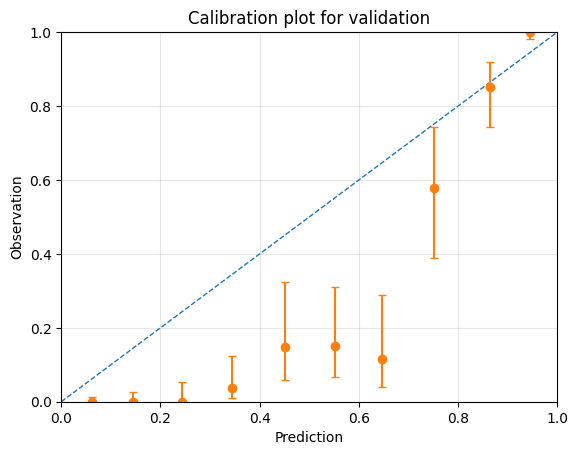

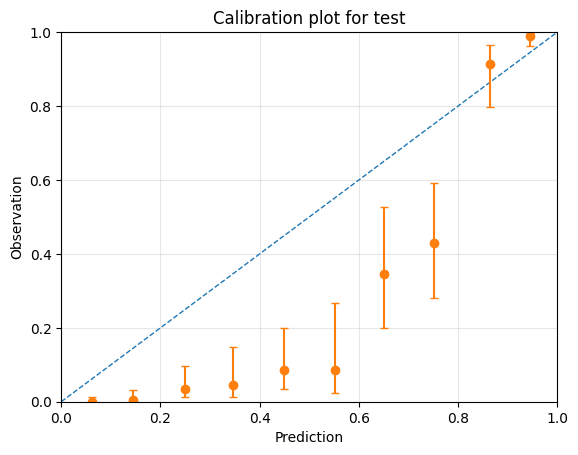

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Binomial CI (Wilson)
# -------------------------
def wilson_ci(k: int, n: int, z: float = 1.96):
    """Wilson score interval for a binomial proportion."""
    if n <= 0:
        return (np.nan, np.nan)
    phat = k / n
    denom = 1.0 + (z*z)/n
    center = (phat + (z*z)/(2*n)) / denom
    half = (z * np.sqrt((phat*(1-phat) + (z*z)/(4*n)) / n)) / denom
    lo = max(0.0, center - half)
    hi = min(1.0, center + half)
    return lo, hi

# -------------------------
# Make calibration bins
# -------------------------
def calibration_bins(probs, targs, n_bins: int = 10, binning: str = "uniform"):
    """
    Returns arrays per non-empty bin:
      mean_pred, frac_pos, ci_low, ci_high, counts
    """
    probs = np.asarray(probs, dtype=np.float64).reshape(-1)
    targs = np.asarray(targs, dtype=int).reshape(-1)

    # safety (in case of tiny numeric drift)
    probs = np.clip(probs, 0.0, 1.0)

    if binning == "uniform":
        edges = np.linspace(0.0, 1.0, n_bins + 1)
    elif binning == "quantile":
        # quantile bins can collapse if many ties; fall back to uniform
        edges = np.quantile(probs, np.linspace(0.0, 1.0, n_bins + 1))
        edges[0], edges[-1] = 0.0, 1.0
        edges = np.unique(edges)
        if len(edges) < 3:
            edges = np.linspace(0.0, 1.0, n_bins + 1)
    else:
        raise ValueError("binning must be 'uniform' or 'quantile'")

    # assign bins
    # right=True makes the last edge inclusive, reducing edge weirdness
    bin_ids = np.digitize(probs, edges, right=True) - 1
    bin_ids = np.clip(bin_ids, 0, len(edges) - 2)

    mean_pred, frac_pos, lo, hi, counts = [], [], [], [], []

    for b in range(len(edges) - 1):
        m = (bin_ids == b)
        n = int(m.sum())
        if n == 0:
            continue

        p_mean = float(probs[m].mean())
        k = int(targs[m].sum())
        obs = k / n

        ci_lo, ci_hi = wilson_ci(k, n, z=1.96)

        mean_pred.append(p_mean)
        frac_pos.append(obs)
        lo.append(ci_lo)
        hi.append(ci_hi)
        counts.append(n)

    return (np.array(mean_pred), np.array(frac_pos),
            np.array(lo), np.array(hi), np.array(counts))

# -------------------------
# Plot (errorbar style like your screenshot)
# -------------------------
def plot_calibration_errorbar(probs, targs, n_bins: int = 10, title: str = "Calibration",
                              xlim=(0, 1), ylim=(0, 1),
                              binning: str = "uniform",
                              group=None, group_names=None,
                              show_counts: bool = False):
    """
    Points: mean predicted probability per bin
    Error bars: Wilson 95% CI for observed fraction of positives per bin
    Optional grouping (e.g., sex): supply group array aligned with probs/targs.
    """
    probs = np.asarray(probs).reshape(-1)
    targs = np.asarray(targs).reshape(-1)

    plt.figure()
    # perfect calibration line
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    def _draw_one(p, y, label=None):
        mp, fp, lo, hi, cnt = calibration_bins(p, y, n_bins=n_bins, binning=binning)

        # IMPORTANT: Matplotlib needs non-negative error lengths
        err_low = np.maximum(0.0, fp - lo)
        err_hi  = np.maximum(0.0, hi - fp)

        # drop any non-finite values (extra safety)
        mask = np.isfinite(mp) & np.isfinite(fp) & np.isfinite(err_low) & np.isfinite(err_hi)
        mp, fp, err_low, err_hi, cnt = mp[mask], fp[mask], err_low[mask], err_hi[mask], cnt[mask]

        plt.errorbar(mp, fp, yerr=np.vstack([err_low, err_hi]),
                     fmt="o", capsize=3, label=label)

        if show_counts:
            for x, yv, n in zip(mp, fp, cnt):
                plt.text(x, yv, str(int(n)), fontsize=8, ha="left", va="bottom")

    if group is None:
        _draw_one(probs, targs, label=None)
    else:
        group = np.asarray(group).reshape(-1)
        uniq = np.unique(group)
        for g in uniq:
            m = (group == g)
            label = str(g)
            if group_names is not None and g in group_names:
                label = group_names[g]
            _draw_one(probs[m], targs[m], label=label)
        plt.legend(title="group")

    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.xlabel("Prediction")
    plt.ylabel("Observation")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

# Validation
plot_calibration_errorbar(val_probs, val_targs, n_bins=10,
                          title="Calibration plot for validation",
                          xlim=(0,1), ylim=(0,1))

# Test
plot_calibration_errorbar(test_probs, test_targs, n_bins=10,
                          title="Calibration plot for test",
                          xlim=(0,1), ylim=(0,1))


# Confidence Plots


EXTRACTING HUMAN CONFIDENCE FROM PTB-XL DATABASE

[Debug] Current directory: /scratch1/e20-fyp-ecg-ihd-detection/experiments_new/Mamba2_DatasetD_ValTest_Pure
✅ Found PTB-XL metadata at: /scratch1/e20-fyp-ecg-ihd-detection/experiments_new/csvs/ptbxl_database.csv
✅ Loaded ptbxl_df: 21799 rows
✅ scp_lookup ready

[Debug] Looking for CSV at: /scratch1/e20-fyp-ecg-ihd-detection/experiments_new/csvs/ptbxl_dataset_test_certain_vs_normal.csv

✅ Found test CSV at: /scratch1/e20-fyp-ecg-ihd-detection/experiments_new/csvs/ptbxl_dataset_test_certain_vs_normal.csv

[Step 1] Loading test CSV to extract ECG IDs...
✅ Loaded test CSV: 971 samples
✅ Extracted 971 ECG IDs
   Sample ECG IDs: [ 9 38 57 59 75]

[Step 2] Verifying order consistency...
✅ Order verification: 971/971 match (100.0%)

[Step 3] Extracting human confidence scores from PTB-XL...

✅ Human confidence extraction complete!
   Valid scores: 971/971 (100.0%)
   Mean:  0.275
   Std:   0.446
   Range: [0.000, 1.000]

📊 Human confidence by 

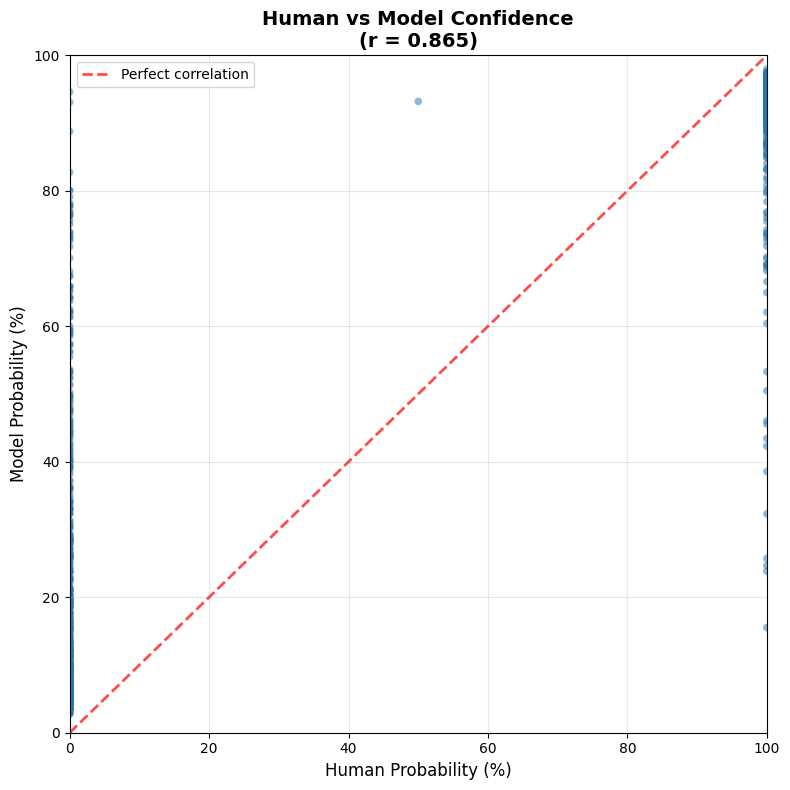


📊 Correlation: r=0.8648, p=4.1493e-292, n=971

📈 Plot 2: Model Confidence by Outcome


/tmp/ipykernel_874743/3983759921.py:218: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([tp_probs, fn_probs, fp_probs],


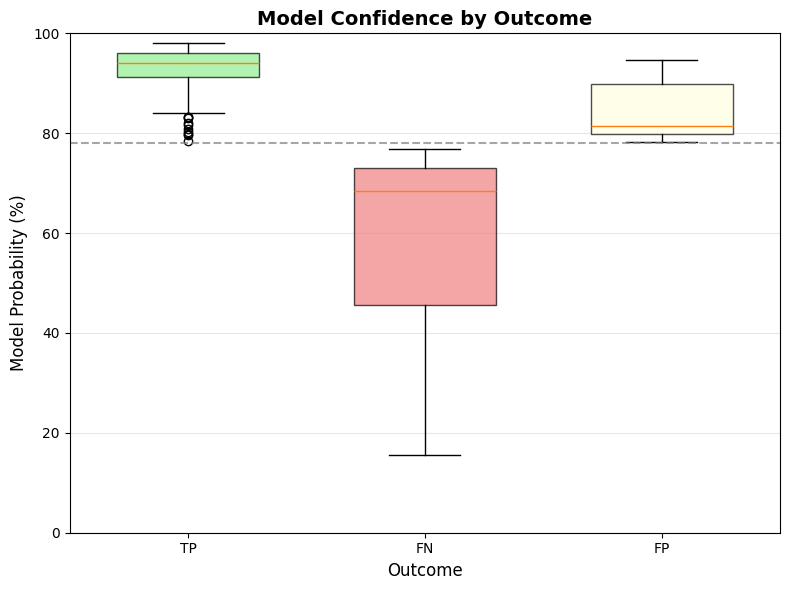


📊 TP:  234 | mean=93.0% | median=94.1%
   FN:   34 | mean=58.8% | median=68.4%
   FP:    8 | mean=84.6% | median=81.4%

📈 Plot 3: Binned Confidence Analysis


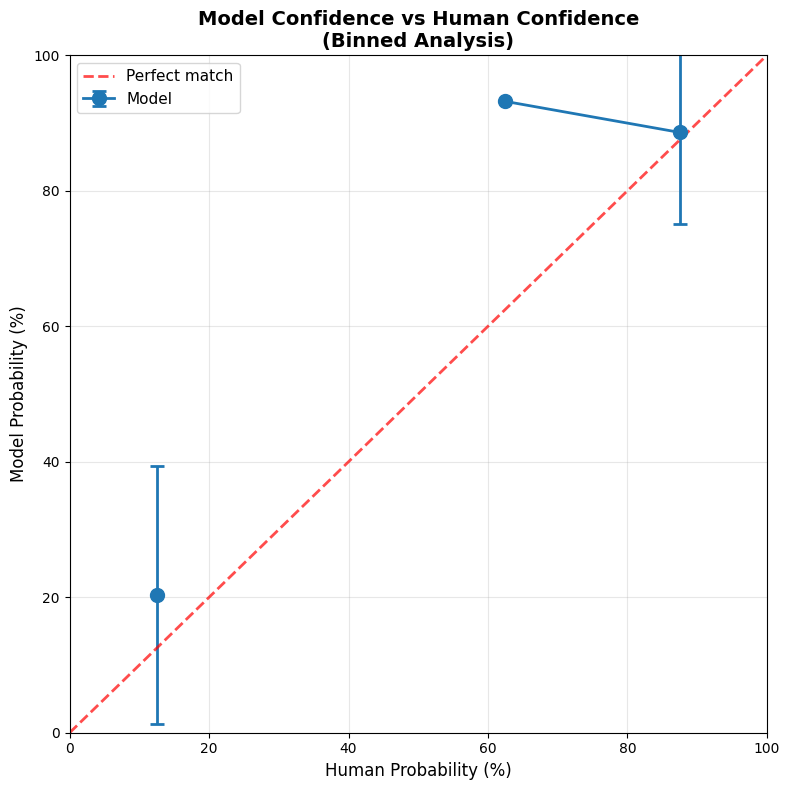


📊 Binned Analysis:
   0-25%     :  703 samples |  20.3% ±  19.0%
   25-50%    :    0 samples | (no samples)
   50-75%    :    1 samples |  93.2% ±   0.0%
   75-100%   :  267 samples |  88.6% ±  13.6%

✅ All plots generated successfully!


In [23]:
print("\n" + "="*60)
print("EXTRACTING HUMAN CONFIDENCE FROM PTB-XL DATABASE")
print("="*60)

# ------------------------------------------------------------
# 0) Load PTB-XL master metadata (ptbxl_database.csv) -> ptbxl_df
# ------------------------------------------------------------
print(f"\n[Debug] Current directory: {os.getcwd()}")

PTBXL_DB_CANDIDATES = [
    "/scratch1/e20-fyp-ecg-ihd-detection/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv",
    "/scratch1/e20-fyp-ecg-ihd-detection/datasets/ptbxl/ptbxl_database.csv",
    "/scratch1/e20-fyp-ecg-ihd-detection/data/ptbxl/ptbxl_database.csv",
    "/scratch1/e20-fyp-ecg-ihd-detection/ptbxl_database.csv",
]

ptbxl_db_path = "/scratch1/e20-fyp-ecg-ihd-detection/experiments_new/csvs/ptbxl_database.csv"
for p in PTBXL_DB_CANDIDATES:
    if os.path.exists(p):
        ptbxl_db_path = p
        break

if ptbxl_db_path is None:
    raise FileNotFoundError(
        "❌ Could not find ptbxl_database.csv.\n"
        "Run: !find /scratch1/e20-fyp-ecg-ihd-detection -name 'ptbxl_database.csv' 2>/dev/null\n"
        "Then add the found path to PTBXL_DB_CANDIDATES."
    )

print(f"✅ Found PTB-XL metadata at: {ptbxl_db_path}")
ptbxl_df = pd.read_csv(ptbxl_db_path)

required_cols = {"ecg_id", "scp_codes"}
missing = required_cols - set(ptbxl_df.columns)
if missing:
    raise ValueError(f"❌ ptbxl_database.csv missing columns: {missing}")

# fast lookup: ecg_id -> scp_codes string
scp_lookup = dict(
    zip(ptbxl_df["ecg_id"].astype(int).values, ptbxl_df["scp_codes"].values)
)

print(f"✅ Loaded ptbxl_df: {len(ptbxl_df)} rows")
print("✅ scp_lookup ready\n")


# ------------------------------------------------------------
# 1) Find your test CSV and read ecg_id list
# ------------------------------------------------------------
CSV_DIR = "/scratch1/e20-fyp-ecg-ihd-detection/experiments_new/csvs"
TEST_CSV = os.path.join(CSV_DIR, "/scratch1/e20-fyp-ecg-ihd-detection/experiments_new/csvs/ptbxl_dataset_test_certain_vs_normal.csv")

print(f"[Debug] Looking for CSV at: {TEST_CSV}")

if not os.path.exists(TEST_CSV):
    print(f"❌ CSV not found at {TEST_CSV}")
    alternatives = [
        "../../csvs/ptbxl_dataset_test.csv",
        "../../../csvs/ptbxl_dataset_test.csv",
        "/scratch1/e20-fyp-ecg-ihd-detection/csvs/ptbxl_dataset_test.csv",
    ]
    for alt in alternatives:
        print(f"   Trying: {alt}")
        if os.path.exists(alt):
            TEST_CSV = alt
            print(f"   ✅ Found at: {alt}")
            break

if not os.path.exists(TEST_CSV):
    raise FileNotFoundError("❌ Could not find ptbxl_dataset_test.csv")

print(f"\n✅ Found test CSV at: {TEST_CSV}")
print("\n[Step 1] Loading test CSV to extract ECG IDs...")
df_test_csv = pd.read_csv(TEST_CSV)
print(f"✅ Loaded test CSV: {len(df_test_csv)} samples")

if "ecg_id" not in df_test_csv.columns:
    raise ValueError(f"❌ 'ecg_id' column not found. Available: {df_test_csv.columns.tolist()}")

test_ecg_ids = df_test_csv["ecg_id"].astype(int).values
print(f"✅ Extracted {len(test_ecg_ids)} ECG IDs")
print(f"   Sample ECG IDs: {test_ecg_ids[:5]}")


# ------------------------------------------------------------
# 2) Verify order consistency with your current test loader
#    (requires groups_test already existing)
# ------------------------------------------------------------
if "groups_test" in globals() and "main_3group" in df_test_csv.columns:
    print(f"\n[Step 2] Verifying order consistency...")
    groups_from_csv = df_test_csv["main_3group"].values
    if len(groups_test) == len(groups_from_csv):
        matches = int((groups_test == groups_from_csv).sum())
        match_rate = matches / len(groups_test)
        print(f"✅ Order verification: {matches}/{len(groups_test)} match ({match_rate*100:.1f}%)")
        if match_rate <= 0.95:
            print("⚠️ Low match rate - your test loader may be shuffled.")
    else:
        print("⚠️ groups_test length mismatch with CSV; skipping alignment check.")
else:
    print("ℹ️ groups_test not found (or main_3group missing) — skipping order check.")


# ------------------------------------------------------------
# 3) Extract MI likelihood from PTB-XL scp_codes
# ------------------------------------------------------------
MI_CODES = [
    "IMI", "AMI", "LMI", "ASMI", "ILMI", "ALMI",
    "INJAS", "INJAL", "IPLMI", "IPMI", "INJIN", "INJLA", "PMI"
]

def extract_mi_likelihood_from_ptbxl(ecg_ids, scp_lookup, mi_codes=MI_CODES):
    """
    Returns human_probs in [0,1] for each ecg_id.
    Uses max likelihood among MI-related SCP codes.
    """
    human = np.full(len(ecg_ids), np.nan, dtype=np.float64)

    for i, ecg_id in enumerate(ecg_ids):
        scp_str = scp_lookup.get(int(ecg_id), None)
        if scp_str is None or (isinstance(scp_str, float) and np.isnan(scp_str)):
            continue

        try:
            scp = ast.literal_eval(scp_str)  # dict
        except Exception:
            continue

        mx = 0.0
        for code in mi_codes:
            if code in scp:
                mx = max(mx, float(scp[code]))

        human[i] = mx / 100.0

    return human

print(f"\n[Step 3] Extracting human confidence scores from PTB-XL...")
human_probs = extract_mi_likelihood_from_ptbxl(test_ecg_ids, scp_lookup)

valid_count = int(np.sum(~np.isnan(human_probs)))
print(f"\n✅ Human confidence extraction complete!")
print(f"   Valid scores: {valid_count}/{len(human_probs)} ({valid_count/len(human_probs)*100:.1f}%)")

if valid_count > 0:
    print(f"   Mean:  {np.nanmean(human_probs):.3f}")
    print(f"   Std:   {np.nanstd(human_probs):.3f}")
    print(f"   Range: [{np.nanmin(human_probs):.3f}, {np.nanmax(human_probs):.3f}]")

    # distribution by group (if groups_test exists)
    if "groups_test" in globals():
        print(f"\n📊 Human confidence by test group:")
        for group in np.unique(groups_test):
            mask = (groups_test == group)
            vals = human_probs[mask]
            vals = vals[~np.isnan(vals)]
            if len(vals) > 0:
                print(f"   {str(group):15s}: n={len(vals):4d} | mean={vals.mean():.3f} | std={vals.std():.3f}")
else:
    print("⚠️ No valid human confidence scores found (all NaN).")


# =========================
# PLOTTING FUNCTIONS
# =========================

def plot_human_vs_model_confidence(human_probs, model_probs, test_targs):
    """Scatter plot: Human vs Model Confidence"""
    from scipy.stats import pearsonr

    human_probs = np.asarray(human_probs).reshape(-1)
    model_probs = np.asarray(model_probs).reshape(-1)
    test_targs = np.asarray(test_targs).reshape(-1)

    valid_mask = np.isfinite(human_probs)
    if valid_mask.sum() < 10:
        print("⚠️ Not enough valid samples for correlation plot")
        return

    h_valid = human_probs[valid_mask] * 100
    m_valid = model_probs[valid_mask] * 100

    correlation, p_value = pearsonr(human_probs[valid_mask], model_probs[valid_mask])

    plt.figure(figsize=(8, 8))
    plt.scatter(h_valid, m_valid, alpha=0.5, s=30, edgecolors='none')
    plt.plot([0, 100], [0, 100], 'r--', label='Perfect correlation', linewidth=2, alpha=0.7)

    plt.xlabel('Human Probability (%)', fontsize=12)
    plt.ylabel('Model Probability (%)', fontsize=12)
    plt.title(f'Human vs Model Confidence\n(r = {correlation:.3f})', fontsize=14, fontweight='bold')
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f"\n📊 Correlation: r={correlation:.4f}, p={p_value:.4e}, n={valid_mask.sum()}")


def plot_confidence_by_outcome(model_probs, test_targs, threshold=0.5):
    """Box plot: Model Confidence by Outcome (TP/FN/FP)"""
    model_probs = np.asarray(model_probs).reshape(-1)
    test_targs = np.asarray(test_targs).reshape(-1)

    predictions = (model_probs >= threshold).astype(int)

    tp_mask = (predictions == 1) & (test_targs == 1)
    fn_mask = (predictions == 0) & (test_targs == 1)
    fp_mask = (predictions == 1) & (test_targs == 0)

    tp_probs = model_probs[tp_mask] * 100
    fn_probs = model_probs[fn_mask] * 100
    fp_probs = model_probs[fp_mask] * 100

    plt.figure(figsize=(8, 6))
    bp = plt.boxplot([tp_probs, fn_probs, fp_probs],
                     labels=['TP', 'FN', 'FP'],
                     patch_artist=True, widths=0.6)

    colors = ['lightgreen', 'lightcoral', 'lightyellow']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    plt.axhline(y=threshold*100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    plt.ylabel('Model Probability (%)', fontsize=12)
    plt.xlabel('Outcome', fontsize=12)
    plt.title('Model Confidence by Outcome', fontsize=14, fontweight='bold')
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    def _safe_mean(x): return float(np.mean(x)) if len(x) else float("nan")
    def _safe_med(x):  return float(np.median(x)) if len(x) else float("nan")

    print(f"\n📊 TP: {len(tp_probs):4d} | mean={_safe_mean(tp_probs):.1f}% | median={_safe_med(tp_probs):.1f}%")
    print(f"   FN: {len(fn_probs):4d} | mean={_safe_mean(fn_probs):.1f}% | median={_safe_med(fn_probs):.1f}%")
    print(f"   FP: {len(fp_probs):4d} | mean={_safe_mean(fp_probs):.1f}% | median={_safe_med(fp_probs):.1f}%")


def plot_binned_confidence_analysis(human_probs, model_probs, n_bins=4):
    """Binned analysis: Model vs Human Confidence"""
    human_probs = np.asarray(human_probs).reshape(-1)
    model_probs = np.asarray(model_probs).reshape(-1)

    valid_mask = np.isfinite(human_probs)
    if valid_mask.sum() < 10:
        print("⚠️ Not enough valid samples for binned analysis")
        return

    h_valid = human_probs[valid_mask]
    m_valid = model_probs[valid_mask]

    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2 * 100

    means, stds, counts = [], [], []
    for i in range(n_bins):
        # include last edge in last bin
        if i == n_bins - 1:
            mask = (h_valid >= bins[i]) & (h_valid <= bins[i+1])
        else:
            mask = (h_valid >= bins[i]) & (h_valid < bins[i+1])

        counts.append(int(mask.sum()))
        if np.any(mask):
            means.append(float((m_valid[mask] * 100).mean()))
            stds.append(float((m_valid[mask] * 100).std()))
        else:
            means.append(np.nan)
            stds.append(np.nan)

    plt.figure(figsize=(8, 8))
    plt.errorbar(bin_centers, means, yerr=stds, marker='o', markersize=10,
                 capsize=5, capthick=2, label='Model',
                 linewidth=2, elinewidth=2)
    plt.plot([0, 100], [0, 100], 'r--', label='Perfect match', linewidth=2, alpha=0.7)

    plt.xlabel('Human Probability (%)', fontsize=12)
    plt.ylabel('Model Probability (%)', fontsize=12)
    plt.title('Model Confidence vs Human Confidence\n(Binned Analysis)', fontsize=14, fontweight='bold')
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f"\n📊 Binned Analysis:")
    for i, (mean, std, count) in enumerate(zip(means, stds, counts)):
        bin_range = f"{bins[i]*100:.0f}-{bins[i+1]*100:.0f}%"
        if not np.isnan(mean):
            print(f"   {bin_range:10s}: {count:4d} samples | {mean:5.1f}% ± {std:5.1f}%")
        else:
            print(f"   {bin_range:10s}: {count:4d} samples | (no samples)")


# =========================
# GENERATE PLOTS
# =========================
if human_probs is not None and np.isfinite(human_probs).sum() > 0:
    print("\n" + "="*60)
    print("GENERATING CONFIDENCE ANALYSIS PLOTS")
    print("="*60)

    print("\n📈 Plot 1: Human vs Model Confidence")
    plot_human_vs_model_confidence(human_probs, test_probs, test_targs)

    print("\n📈 Plot 2: Model Confidence by Outcome")
    thr = tuned_thr if "tuned_thr" in globals() else 0.5
    plot_confidence_by_outcome(test_probs, test_targs, threshold=thr)

    print("\n📈 Plot 3: Binned Confidence Analysis")
    plot_binned_confidence_analysis(human_probs, test_probs, n_bins=4)

    print("\n✅ All plots generated successfully!")
else:
    print("\n❌ Cannot generate plots: No valid human confidence data")
